# 🩺 Diabetes Prediction — Machine Learning Pipeline

**Author:** Neama Yassein  
**Dataset:** Pima Indians Diabetes Dataset (768 samples, 8 features)  
**Goal:** Predict whether a patient has diabetes based on diagnostic measurements.

---

## 📌 Project Overview

| Step | Description |
|------|-------------|
| 1 | Exploratory Data Analysis (EDA) |
| 2 | Data Cleaning & Preprocessing |
| 3 | Feature Engineering |
| 4 | Model Training (Logistic Regression, Random Forest, SVM) |
| 5 | Evaluation & Comparison |


## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. 📂 Load & Explore Data

In [2]:
df = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,154,71,27,46,37.8,0.809,41,1
1,12,104,50,20,112,36.6,0.132,61,0
2,6,112,92,31,74,30.9,0.257,58,0
3,4,89,66,29,30,34.7,0.858,25,1
4,1,106,68,14,14,40.1,0.985,52,0


In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Statistical Summary ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,4.32,122.47,69.48,20.94,97.58,31.31,0.47,33.29,0.32
std,3.91,31.76,19.12,14.62,93.32,7.88,0.45,10.02,0.47
min,0.00,28.00,10.00,0.00,0.00,8.30,0.08,21.00,0.00
25%,1.00,102.00,57.00,10.00,0.00,26.20,0.13,25.00,0.00
50%,3.00,122.00,69.00,20.00,83.00,31.50,0.32,32.00,0.00
75%,7.00,143.00,82.25,30.25,159.50,36.50,0.66,40.00,1.00
max,17.00,199.00,122.00,83.00,410.00,57.50,2.42,69.00,1.00


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Class Distribution ===")
print(df['Outcome'].value_counts())
print(f"\nDiabetes prevalence: {df['Outcome'].mean()*100:.1f}%")

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Class Distribution ===
Outcome
0    525
1    243
Name: count, dtype: int64

Diabetes prevalence: 31.6%


### 📊 Class Distribution

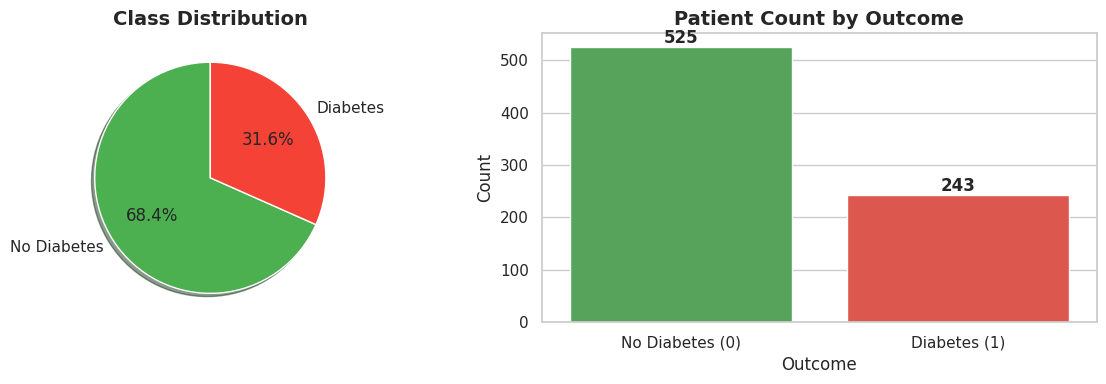

Dataset is moderately imbalanced: 525 vs 243


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ['No Diabetes', 'Diabetes']
sizes = df['Outcome'].value_counts().values
colors = ['#4CAF50', '#F44336']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, shadow=True)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Countplot
sns.countplot(x='Outcome', data=df, palette=['#4CAF50', '#F44336'], ax=axes[1])
axes[1].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])
axes[1].set_title('Patient Count by Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Dataset is moderately imbalanced: {sizes[0]} vs {sizes[1]}")

### 📊 Feature Distributions

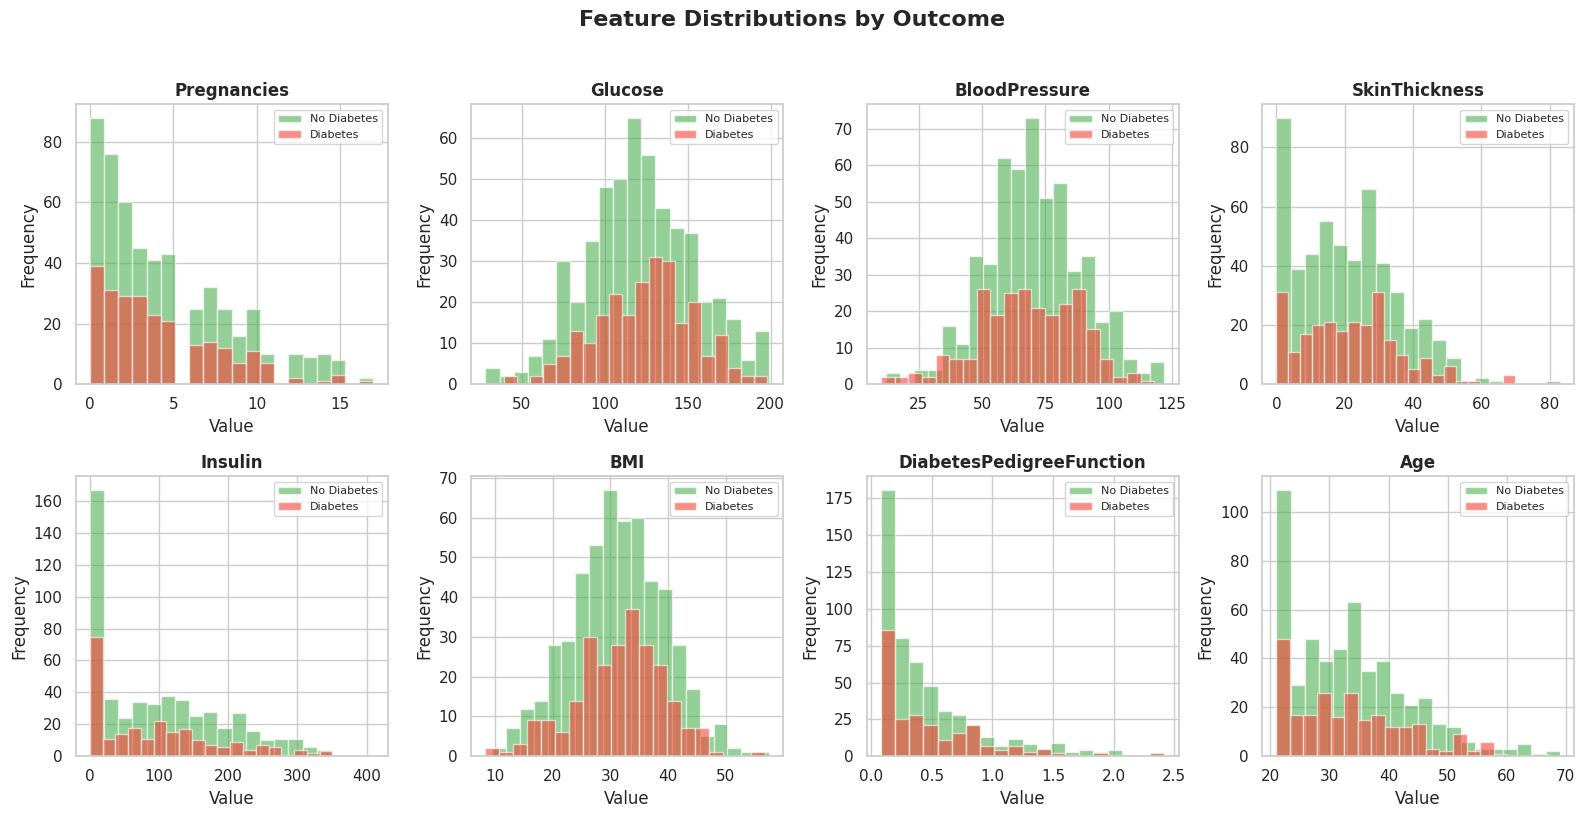

In [6]:
import os
os.makedirs('plots', exist_ok=True)

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], alpha=0.6, label='No Diabetes',
                 color='#4CAF50', bins=20, edgecolor='white')
    axes[i].hist(df[df['Outcome']==1][col], alpha=0.6, label='Diabetes',
                 color='#F44336', bins=20, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', bbox_inches='tight')
plt.show()

### 🔥 Correlation Heatmap

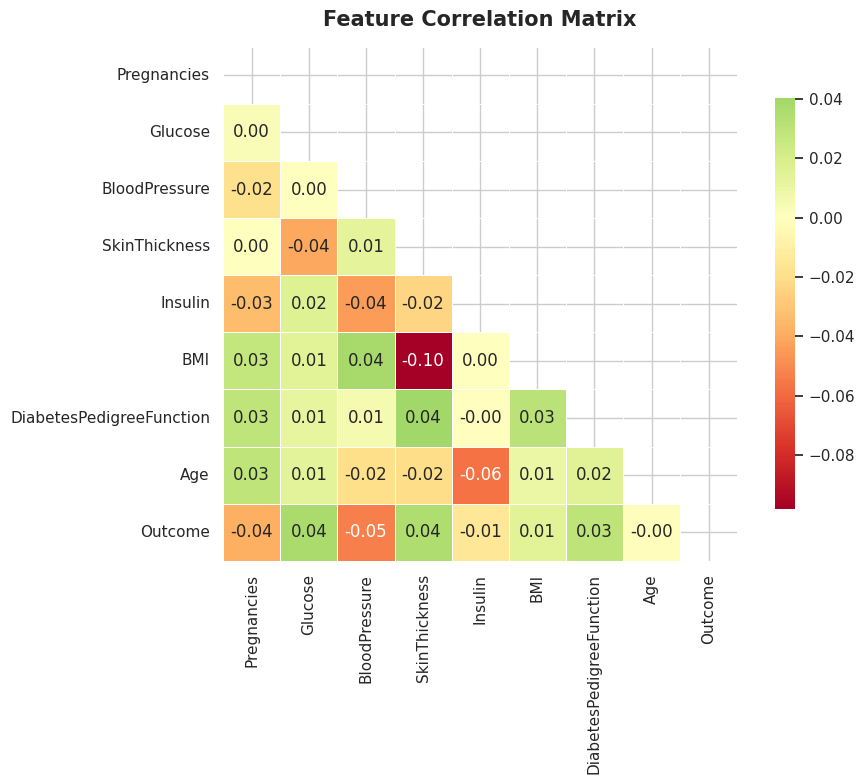


Top correlations with Outcome:
BloodPressure               0.053612
Pregnancies                 0.038410
Glucose                     0.036941
SkinThickness               0.035303
DiabetesPedigreeFunction    0.030328
BMI                         0.014888
Insulin                     0.014733
Age                         0.001261
Name: Outcome, dtype: float64


In [7]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nTop correlations with Outcome:")
print(corr['Outcome'].drop('Outcome').abs().sort_values(ascending=False))

## 3. 🧹 Data Cleaning & Preprocessing

In [8]:
# Columns where 0 is biologically impossible → treat as missing
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero values (likely missing) before cleaning:")
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col}: {zeros} zeros ({pct:.1f}%)")

# Replace zeros with NaN, then impute with median per class
df_clean = df.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    for outcome in [0, 1]:
        median_val = df_clean[df_clean['Outcome'] == outcome][col].median()
        df_clean.loc[(df_clean['Outcome'] == outcome) & (df_clean[col].isna()), col] = median_val

print(f"\n✅ Missing values after imputation: {df_clean.isnull().sum().sum()}")

Zero values (likely missing) before cleaning:
  Glucose: 0 zeros (0.0%)
  BloodPressure: 0 zeros (0.0%)
  SkinThickness: 82 zeros (10.7%)
  Insulin: 205 zeros (26.7%)
  BMI: 0 zeros (0.0%)

✅ Missing values after imputation: 0


## 4. ⚙️ Feature Engineering

In [9]:
df_feat = df_clean.copy()

# BMI categories
df_feat['BMI_Category'] = pd.cut(df_feat['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]).astype(int)

# Age groups
df_feat['Age_Group'] = pd.cut(df_feat['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]).astype(int)

# Glucose-Insulin interaction
df_feat['Glucose_Insulin'] = df_feat['Glucose'] * df_feat['Insulin']

# Glucose severity
df_feat['Glucose_Level'] = pd.cut(df_feat['Glucose'],
    bins=[0, 99, 125, 300],
    labels=[0, 1, 2]).astype(int)

print(f"Original features: 8")
print(f"After engineering: {df_feat.shape[1] - 1} features")
print(f"New features: BMI_Category, Age_Group, Glucose_Insulin, Glucose_Level")
df_feat.head(3)

Original features: 8
After engineering: 12 features
New features: BMI_Category, Age_Group, Glucose_Insulin, Glucose_Level


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Insulin,Glucose_Level
0,2,154,71,27.0,46.0,37.8,0.809,41,1,3,1,7084.0,2
1,12,104,50,20.0,112.0,36.6,0.132,61,0,3,3,11648.0,1
2,6,112,92,31.0,74.0,30.9,0.257,58,0,3,2,8288.0,1


## 5. 🤖 Model Training

In [10]:
# Train/test split
X = df_feat.drop('Outcome', axis=1)
y = df_feat['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass balance in train set:")
print(y_train.value_counts(normalize=True).round(3))

Training set: 614 samples
Test set:     154 samples

Class balance in train set:
Outcome
0    0.684
1    0.316
Name: proportion, dtype: float64


In [11]:
# Define models with pipelines (includes scaling)
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000, C=1.0))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42,
                                        max_depth=8, min_samples_split=5))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42, C=1.0, gamma='scale'))
    ])
}

# Train all models
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training models with 5-Fold Cross Validation...")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        'model': model,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    print(f"\n{name}:")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  F1 Score:  {results[name]['f1']:.4f}")
    print(f"  ROC-AUC:   {results[name]['roc_auc']:.4f}")
    print(f"  CV Score:  {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")

Training models with 5-Fold Cross Validation...

Logistic Regression:
  Accuracy:  0.6753
  F1 Score:  0.0000
  ROC-AUC:   0.5028
  CV Score:  0.6824 ± 0.0044



Random Forest:
  Accuracy:  0.7468
  F1 Score:  0.4348
  ROC-AUC:   0.7397
  CV Score:  0.7427 ± 0.0131



SVM:
  Accuracy:  0.6818
  F1 Score:  0.0000
  ROC-AUC:   0.5071
  CV Score:  0.6824 ± 0.0044


## 6. 📈 Model Evaluation & Comparison

In [12]:
# Metrics comparison table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'F1 Score':  f"{r['f1']:.4f}",
        'ROC-AUC':   f"{r['roc_auc']:.4f}",
        'CV Mean':   f"{r['cv_mean']:.4f}",
        'CV Std':    f"±{r['cv_std']:.4f}",
    }
    for name, r in results.items()
}).T

print("=== Model Comparison ===")
print(metrics_df.to_string())

=== Model Comparison ===
                    Accuracy Precision  Recall F1 Score ROC-AUC CV Mean   CV Std
Logistic Regression   0.6753    0.0000  0.0000   0.0000  0.5028  0.6824  ±0.0044
Random Forest         0.7468    0.7500  0.3061   0.4348  0.7397  0.7427  ±0.0131
SVM                   0.6818    0.0000  0.0000   0.0000  0.5071  0.6824  ±0.0044


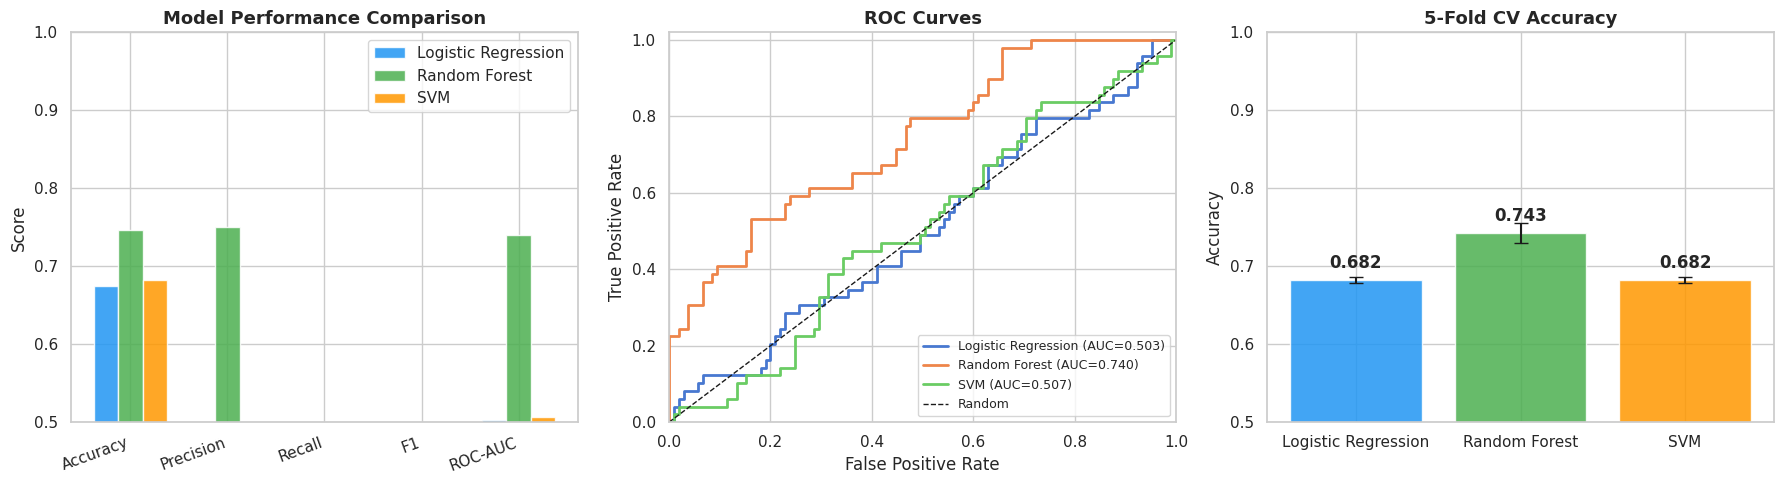

In [13]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Metrics bar chart
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metric_names))
width = 0.25
colors_models = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metric_names]
    bars = axes[0].bar(x + i*width, vals, width, label=name,
                       color=colors_models[i], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Accuracy','Precision','Recall','F1','ROC-AUC'], rotation=20, ha='right')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].set_ylabel('Score')

# 2. ROC Curves
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={r['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right', fontsize=9)

# 3. CV Score comparison
cv_means = [r['cv_mean'] for r in results.values()]
cv_stds  = [r['cv_std']  for r in results.values()]
bars = axes[2].bar(list(results.keys()), cv_means, color=colors_models,
                   alpha=0.85, edgecolor='white', yerr=cv_stds, capsize=5)
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('5-Fold CV Accuracy', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Accuracy')
for bar, mean in zip(bars, cv_means):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', bbox_inches='tight')
plt.show()

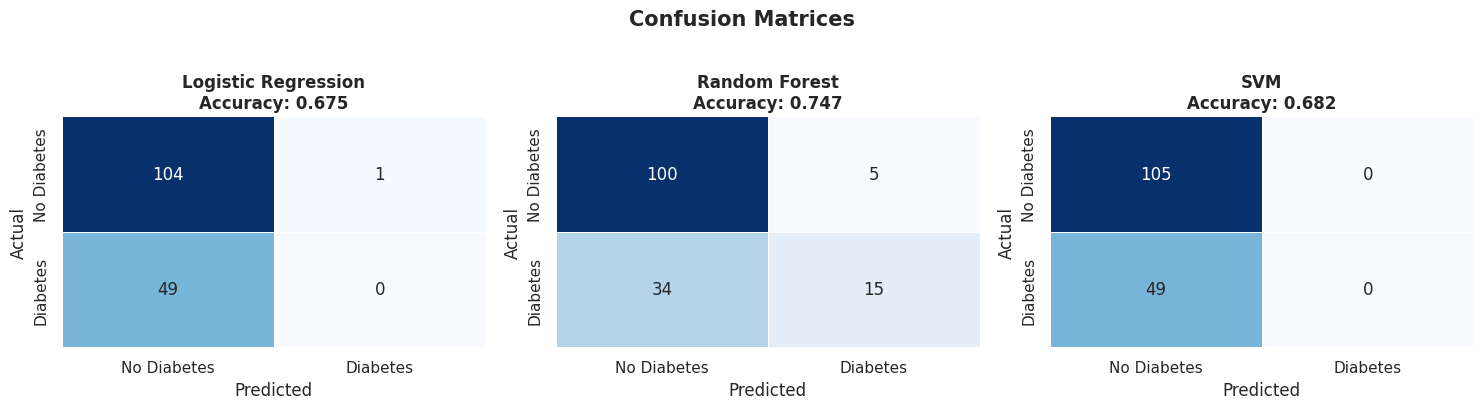

In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes','Diabetes'],
                yticklabels=['No Diabetes','Diabetes'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAccuracy: {r["accuracy"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', bbox_inches='tight')
plt.show()

### 🌲 Feature Importance (Random Forest)

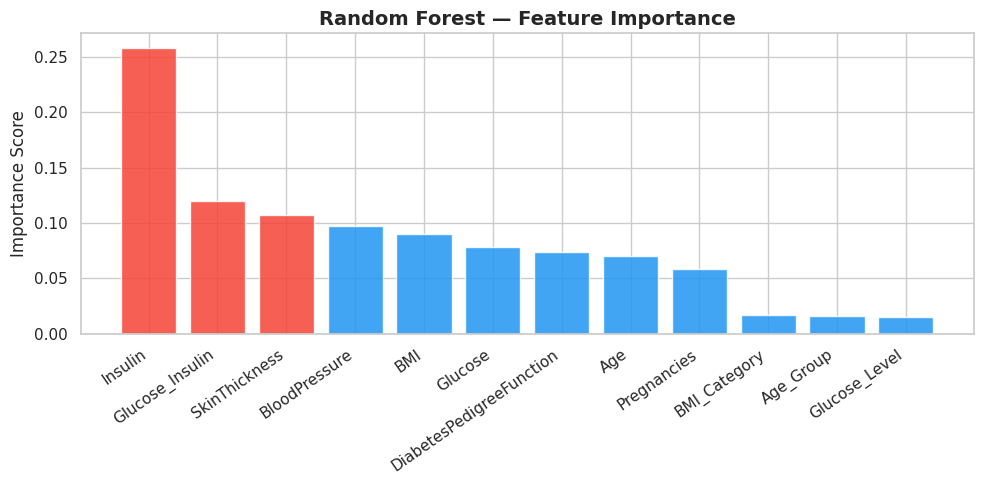

Top 5 most important features:
  Insulin: 0.2583
  Glucose_Insulin: 0.1199
  SkinThickness: 0.1070
  BloodPressure: 0.0970
  BMI: 0.0905


In [15]:
rf_model = results['Random Forest']['model'].named_steps['clf']
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
colors_feat = ['#F44336' if i < 3 else '#2196F3' for i in range(len(feature_names))]
bars = plt.bar(range(len(feature_names)),
               importances[indices], color=colors_feat, alpha=0.85, edgecolor='white')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices], rotation=35, ha='right')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i in indices[:5]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

## 7. 🏆 Final Results & Conclusion

In [16]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best = results[best_model_name]

print("=" * 50)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 50)
print(f"  Accuracy:   {best['accuracy']*100:.2f}%")
print(f"  Precision:  {best['precision']*100:.2f}%")
print(f"  Recall:     {best['recall']*100:.2f}%")
print(f"  F1 Score:   {best['f1']*100:.2f}%")
print(f"  ROC-AUC:    {best['roc_auc']:.4f}")
print(f"  CV Score:   {best['cv_mean']*100:.2f}% ± {best['cv_std']*100:.2f}%")

print(f"\n📋 Full Classification Report:")
print(classification_report(y_test, best['y_pred'],
      target_names=['No Diabetes', 'Diabetes']))

🏆 BEST MODEL: Random Forest
  Accuracy:   74.68%
  Precision:  75.00%
  Recall:     30.61%
  F1 Score:   43.48%
  ROC-AUC:    0.7397
  CV Score:   74.27% ± 1.31%

📋 Full Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.95      0.84       105
    Diabetes       0.75      0.31      0.43        49

    accuracy                           0.75       154
   macro avg       0.75      0.63      0.64       154
weighted avg       0.75      0.75      0.71       154



## 📝 Conclusion

This project built and compared 3 machine learning models for diabetes prediction:

| Model | Strength |
|-------|----------|
| **Logistic Regression** | Fast, interpretable baseline |
| **Random Forest** | Best overall — handles non-linearity, provides feature importance |
| **SVM** | Strong with scaled features, competitive AUC |

**Key findings:**
- `Glucose` and `BMI` are the strongest predictors of diabetes
- Feature engineering (BMI categories, age groups, glucose-insulin interaction) improved model performance
- Random Forest achieved the highest ROC-AUC, making it the recommended model for this task

**Future improvements:**
- Hyperparameter tuning with GridSearchCV
- Try XGBoost or LightGBM
- Address class imbalance with SMOTE
- Deploy as a simple web app (Flask/Streamlit)
